In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

In [ ]:
# loading original_dataset
df = pd.read_csv(
	'training_dataset/original_dataset.csv',
	on_bad_lines='skip'
)

### Applying Context Limitations

In [ ]:
import pandas as pd
from transformers import AutoTokenizer

# 1. Load the CodeLlama tokenizer
# You can use the specific python fine-tuned version
tokenizer_name = "codellama/CodeLlama-7b-Python-hf"
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

# 2. Define a function to count tokens
def count_tokens(text):
    if pd.isna(text):
        return 0
    # encode() returns the token IDs. We take the length to get the token count.
    return len(tokenizer.encode(str(text), add_special_tokens=True))

# Assuming your dataframe is loaded into a variable named 'df'
print("Counting input tokens (IR)...")
df['input_token'] = df['IR4'].apply(count_tokens)

print("Counting output tokens (OR)...")
df['output_token'] = df['OR2'].apply(count_tokens)


CONTEXT_LIMIT = 1024
include_df = df[(df['input_token'] + df['output_token']) <= CONTEXT_LIMIT]
exclude_df = df[(df['input_token'] + df['output_token']) > CONTEXT_LIMIT]

print(f"Original samples: {len(df)}")
print(f"Samples within context limit: {len(include_df)}")
print(f"Samples out-of context limit: {len(exclude_df)}")

Counting input tokens (IR)...
Counting output tokens (OR)...
Original samples: 92831
Samples within context limit: 91323
Samples out-of context limit: 1508


In [ ]:
print(f"Original samples: {len(df)}")
print(f"Samples within context limit: {len(include_df)}")
print(f"Samples out-of context limit: {len(exclude_df)}")

Original samples: 92831
Samples within context limit: 91323
Samples out-of context limit: 1508


In [ ]:
print("=== DROPPED SAMPLES BY TYPE ===")
print(exclude_df['type'].value_counts())
print(f"\nTotal dropped by type: {len(exclude_df)}")

=== DROPPED SAMPLES BY TYPE ===
type
repairllama    1211
RunBugRun       188
PyResBugs       109
Name: count, dtype: int64

Total dropped by type: 1508


In [ ]:
print("=== DROPPED SAMPLES BY REPO ===")
print(exclude_df['repo'].value_counts())
print(f"\nTotal dropped by repo: {len(exclude_df)}")


=== DROPPED SAMPLES BY REPO ===
repo
RunBugRun                               188
gdsfactory/gdsfactory                   156
PyResBugs                               109
NVIDIA/NeMo                              81
optuna/optuna                            63
                                       ... 
rq/rq                                     1
prompt-toolkit/python-prompt-toolkit      1
sphinx-doc/sphinx                         1
pyglet/pyglet                             1
databricks/koalas                         1
Name: count, Length: 143, dtype: int64

Total dropped by repo: 1508


In [ ]:
print("=== SUMMARY: INCLUDED vs DROPPED ===\n")
print("By Type:")
comparison_type = pd.DataFrame({
    'Total': df['type'].value_counts(),
    'Included': include_df['type'].value_counts(),
    'Dropped': exclude_df['type'].value_counts()
}).fillna(0).astype(int)
print(comparison_type)

print("\n\nBy Repo:")
comparison_repo = pd.DataFrame({
    'Total': df['repo'].value_counts(),
    'Included': include_df['repo'].value_counts(),
    'Dropped': exclude_df['repo'].value_counts()
}).fillna(0).astype(int)
pd.set_option('display.max_rows', None)
print(comparison_repo)
pd.reset_option('display.max_rows')


=== SUMMARY: INCLUDED vs DROPPED ===

By Type:
             Total  Included  Dropped
type                                 
PyResBugs     3499      3390      109
RunBugRun    69973     69785      188
repairllama  19359     18148     1211


By Repo:
                                                   Total  Included  Dropped
repo                                                                       
15r10nk/format-dedent                                  1         1        0
3b1b/manim                                           178       171        7
AssertLang/AssertLang                                  2         1        1
Bogdanp/dramatiq                                      34        34        0
Cadair/jupyter_environment_kernels                     1         1        0
DataDog/dd-trace-py                                    2         2        0
Esquains/study1                                        1         1        0
FEniCS/dolfinx                                       131       110  

In [ ]:
include_df=pd.read_csv('training_dataset/include/train.csv',on_bad_lines='skip')
print(f"Included samples: {len(include_df)}")

print("=== CHECKING FOR DUPLICATE FUNCTION PAIRS ===\n")

# Check for duplicates based on buggy_function and fixed_function
duplicates = include_df.duplicated(subset=['IR4', 'OR2'], keep=False)
num_duplicates = duplicates.sum()

print(f"Total duplicate pairs (IR4 + OR2): {num_duplicates}")
print(f"Number of unique duplicate pairs: {(duplicates).sum() // 2}")

if num_duplicates > 0:
    print("\nDuplicate pairs found:")
    dup_df = include_df[duplicates].sort_values(['IR4', 'OR2'])
    print(dup_df[['type', 'repo', 'IR4', 'OR2']].head(10))
else:
    print("\nNo duplicate pairs found!")


Included samples: 91323
=== CHECKING FOR DUPLICATE FUNCTION PAIRS ===

Total duplicate pairs (IR4 + OR2): 0
Number of unique duplicate pairs: 0

No duplicate pairs found!


In [ ]:
include_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91323 entries, 0 to 91322
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID              91323 non-null  int64 
 1   repo            91323 non-null  object
 2   commit_sha      18148 non-null  object
 3   commit_message  18148 non-null  object
 4   buggy_code      91323 non-null  object
 5   fixed_code      91323 non-null  object
 6   type            91323 non-null  object
 7   buggy_function  91323 non-null  object
 8   fixed_function  91323 non-null  object
 9   IR4             91323 non-null  object
 10  OR2             91323 non-null  object
 11  input_token     91323 non-null  int64 
 12  output_token    91323 non-null  int64 
dtypes: int64(3), object(10)
memory usage: 9.1+ MB


### Removing Bad Pairs (Signature Mismatch, Docstring Only Change, Syntactical Issues)

In [ ]:
import ast
import os
import pandas as pd


class FunctionValidator:
    def __init__(self, csv_path):
        self.csv_path = csv_path
        self.df = pd.read_csv(csv_path)
        self.issues = []
        self.valid_rows = []
        self.invalid_indices = []

    def extract_function_info(self, code):
        """Extract function signature and body — only counts TOP-LEVEL functions."""
        try:
            tree = ast.parse(code.strip())

            # Only count top-level function definitions, not nested ones
            top_level_functions = [
                node for node in ast.iter_child_nodes(tree)
                if isinstance(node, ast.FunctionDef) or isinstance(node, ast.AsyncFunctionDef)
            ]

            if len(top_level_functions) != 1:
                return None, f"Found {len(top_level_functions)} functions, expected 1"

            func = top_level_functions[0]
            sig_line = None
            for line in code.split('\n'):
                if f'def {func.name}' in line:
                    sig_line = line.strip()
                    break

            return {
                'name': func.name,
                'args': ast.get_source_segment(code, func.args) if hasattr(ast, 'get_source_segment') else str(func.args),
                'lineno': func.lineno,
                'signature': sig_line
            }, None
        except SyntaxError as e:
            return None, f"Syntax error: {str(e)}"
        except Exception as e:
            return None, f"Parse error: {str(e)}"

    def extract_function_body(self, code):
        """Extract just the function body without signature"""
        try:
            tree = ast.parse(code.strip())
            top_level_functions = [
                node for node in ast.iter_child_nodes(tree)
                if isinstance(node, ast.FunctionDef) or isinstance(node, ast.AsyncFunctionDef)
            ]

            if len(top_level_functions) != 1:
                return None

            func = top_level_functions[0]
            lines = code.split('\n')

            func_def_line = None
            for i, line in enumerate(lines):
                if f'def {func.name}' in line:
                    func_def_line = i
                    break

            if func_def_line is None:
                return None

            return '\n'.join(lines[func_def_line + 1:])
        except:
            return None

    def validate_row(self, idx, row):
        """Validate a single row"""
        buggy_code = str(row.get('buggy_function', ''))
        fixed_code = str(row.get('fixed_function', ''))

        # Check 1: Both columns exist and are not empty
        if pd.isna(buggy_code) or pd.isna(fixed_code) or buggy_code.strip() == '' or fixed_code.strip() == '':
            return False, "Empty buggy_function or fixed_function"

        # Check 2: Each contains exactly one TOP-LEVEL function (nested functions are fine)
        buggy_info, buggy_err = self.extract_function_info(buggy_code)
        fixed_info, fixed_err = self.extract_function_info(fixed_code)

        if not buggy_info:
            return False, f"Buggy function: {buggy_err}"
        if not fixed_info:
            return False, f"Fixed function: {fixed_err}"

        # Check 3: Function names must match
        if buggy_info['name'] != fixed_info['name']:
            return False, f"Function name mismatch: {buggy_info['name']} vs {fixed_info['name']}"

        # Check 4: Function signatures must match
        if buggy_info['signature'] != fixed_info['signature']:
            return False, "Function signature mismatch"

        # NOTE: Docstring-only change check has been removed.
        # The dataset does not contain such samples, and the AST-based check
        # was producing false positives (e.g., whitespace diffs like i+1 vs i + 1
        # yield identical AST dumps, causing legitimate changes to be rejected).

        return True, "Valid"

    def validate_all(self):
        """Validate all rows in the dataset"""
        print(f"Validating {len(self.df)} rows from {self.csv_path}")
        print("-" * 80)

        for idx, row in self.df.iterrows():
            is_valid, message = self.validate_row(idx, row)

            if is_valid:
                self.valid_rows.append(idx)
            else:
                self.invalid_indices.append(idx)
                self.issues.append({
                    'index': idx,
                    'message': message,
                    'buggy_sample': str(row.get('buggy_function', ''))[:100],
                    'fixed_sample': str(row.get('fixed_function', ''))[:100]
                })

            if (idx + 1) % 100 == 0:
                print(f"Processed {idx + 1} rows...")

        print("-" * 80)
        print(f"\nValidation Results:")
        print(f"✓ Valid rows: {len(self.valid_rows)}")
        print(f"✗ Invalid rows: {len(self.invalid_indices)}")
        print(f"Total rows: {len(self.df)}")

        # Print issue type statistics
        if self.issues:
            issue_counts = {}
            for issue in self.issues:
                label = issue['message']
                issue_counts[label] = issue_counts.get(label, 0) + 1

            print("\n" + "=" * 80)
            print("ISSUE TYPE STATISTICS:")
            print("=" * 80)
            for label, count in sorted(issue_counts.items(), key=lambda x: -x[1]):
                print(f"  [{count:>4}]  {label}")

            print("\n" + "=" * 80)
            print("INVALID ROWS DETAILS (first 20):")
            print("=" * 80)
            for issue in self.issues[:20]:
                print(f"\nRow {issue['index']}: {issue['message']}")
                print(f"  Buggy sample: {issue['buggy_sample']}")
                print(f"  Fixed sample: {issue['fixed_sample']}")

    def create_cleaned_dataset(self, output_path):
        """Create a cleaned dataset with only valid rows, and save invalid rows separately."""
        if self.valid_rows:
            cleaned_df = self.df.iloc[self.valid_rows].reset_index(drop=True)
            cleaned_df.to_csv(output_path, index=False)
            print(f"\n✓ Cleaned dataset saved to {output_path}")
            print(f"  Rows: {len(cleaned_df)} (removed {len(self.invalid_indices)} invalid rows)")
        else:
            print("\n✗ No valid rows found. Cannot create cleaned dataset.")

        # Always save invalid rows with issue labels if any
        if self.invalid_indices:
            invalid_df = self.df.iloc[self.invalid_indices].copy().reset_index(drop=True)
            invalid_df['issue_label'] = [issue['message'] for issue in self.issues]

            base, ext = os.path.splitext(output_path)
            invalid_path = f"{base}_invalid{ext}"
            invalid_df.to_csv(invalid_path, index=False)

            print(f"✗ Invalid rows saved to {invalid_path}")
            print(f"  Rows: {len(invalid_df)}")

            print("\nIssue label breakdown:")
            for label, count in invalid_df['issue_label'].value_counts().items():
                pct = count / len(invalid_df) * 100
                print(f"  {label:<55} {count:>4}  ({pct:.1f}%)")

        return bool(self.valid_rows)

In [3]:
path = '../training_dataset/include/train_cleaned.csv'
df = pd.read_csv(
	path,
	on_bad_lines='skip'
)

In [4]:
len(df)

89553

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92831 entries, 0 to 92830
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID              92831 non-null  int64 
 1   repo            92831 non-null  object
 2   commit_sha      19359 non-null  object
 3   commit_message  19359 non-null  object
 4   buggy_code      92831 non-null  object
 5   fixed_code      92831 non-null  object
 6   type            92831 non-null  object
 7   buggy_function  92831 non-null  object
 8   fixed_function  92831 non-null  object
 9   IR4             92831 non-null  object
 10  OR2             92831 non-null  object
dtypes: int64(1), object(10)
memory usage: 7.8+ MB


In [5]:
df['repo'].value_counts()

repo
RunBugRun                69973
PyResBugs                 3499
gdsfactory/gdsfactory      802
mlflow/mlflow              802
spyder-ide/spyder          778
                         ...  
google/clif                  1
airbnb/streamalert           1
meltano/sdk                  1
pytorch/ao                   1
psf/requests                 1
Name: count, Length: 257, dtype: int64

In [9]:
df['type'].value_counts()

type
RunBugRun      69973
repairllama    19359
PyResBugs       3499
Name: count, dtype: int64

### RUNBUGRUN SAMPLE

In [2]:
df = pd.read_csv(
	'training_dataset/include/cleaned_train.csv',
	on_bad_lines='skip'
)

In [4]:
new_df = df[df['type'] == 'RunBugRun']
index = random.randint(0,len(new_df))
sample = new_df.iloc[index].to_dict()
print("Type: ")
print(sample['type'],end='\n\n')
print("Keys: ")
print(sample.keys(),end='\n\n')
print("Buggy Code: ")
print(sample['buggy_code'],end='\n\n')
print("Fixed Code: ")
print(sample['fixed_code'],end='\n\n')
print("IR4: ")
print(sample['IR4'],end='\n\n')
print("OR2: ")
print(sample['OR2'],end='\n\n')

Type: 
RunBugRun

Keys: 
dict_keys(['ID', 'repo', 'commit_sha', 'commit_message', 'buggy_code', 'fixed_code', 'type', 'buggy_function', 'fixed_function', 'IR4', 'OR2', 'input_token', 'output_token'])

Buggy Code: 
from sys import stdin
from itertools import accumulate
def main():
    #入力
    readline=stdin.readline
    n,m=map(int,readline().split())
    a=list(map(int,readline().split()))

    d=dict()
    for s in accumulate(a):
        x=s%m
        if x not in d:
            d[x]=1
        else:
            d[x]+=1

    ans=d[0]
    for v in d.values():
        ans+=v*(v-1)//2

    print(ans)

if __name__=="__main__":
    main()


Fixed Code: 
from sys import stdin
from itertools import accumulate
def main():
    #入力
    readline=stdin.readline
    n,m=map(int,readline().split())
    a=list(map(int,readline().split()))

    d=dict()
    for s in accumulate(a):
        x=s%m
        if x not in d:
            d[x]=1
        else:
            d[x]+=1

    if 0 in d:
        ans=d[0]


### PYRESBUGS SAMPLE

In [27]:
import random

In [6]:
new_df = df[df['type'] == 'PyResBugs']
index = random.randint(0,len(new_df))
sample = new_df.iloc[index].to_dict()
print("Type: ")
print(sample['type'],end='\n\n')
print("Keys: ")
print(sample.keys(),end='\n\n')
print("Buggy Code: ")
print(sample['buggy_code'],end='\n\n')
print("Fixed Code: ")
print(sample['fixed_code'],end='\n\n')
print("IR4: ")
print(sample['IR4'],end='\n\n')
print("OR2: ")
print(sample['OR2'],end='\n\n')

Type: 
PyResBugs

Keys: 
dict_keys(['ID', 'repo', 'commit_sha', 'commit_message', 'buggy_code', 'fixed_code', 'type', 'buggy_function', 'fixed_function', 'IR4', 'OR2', 'input_token', 'output_token'])

Buggy Code: 
def filter_spans(spans):
	get_sort_key = lambda span: (span.end - span.start, span.start)
	sorted_spans = sorted(spans, key=get_sort_key, reverse=True)
	result = []
	seen_tokens = set()
	for span in sorted_spans:
		if span.start not in seen_tokens and span.end - 1 not in seen_tokens:
			result.append(span)
			seen_tokens.update(range(span.start, span.end))
	return result

Fixed Code: 
def filter_spans(spans):
	get_sort_key = lambda span: (span.end - span.start, -span.start)
	sorted_spans = sorted(spans, key=get_sort_key, reverse=True)
	result = []
	seen_tokens = set()
	for span in sorted_spans:
		if span.start not in seen_tokens and span.end - 1 not in seen_tokens:
			result.append(span)
		seen_tokens.update(range(span.start, span.end))
	result = sorted(result, key=lambda spa

### GitHub Open-Source Repo Samples

In [7]:
new_df_1 = df[df['type'] == 'repairllama']
index = random.randint(0,len(new_df_1))
sample = new_df_1.iloc[index].to_dict()
print("Repo: ")
print(sample['repo'],end="\n\n")
print("Type: ")
print(sample['type'],end='\n\n')
print("Keys: ")
print(sample.keys(),end='\n\n')
print("Buggy Code: ")
print(sample['buggy_code'],end='\n\n')
print("Fixed Code: ")
print(sample['fixed_code'],end='\n\n')
print("IR4: ")
print(sample['IR4'],end='\n\n')
print("OR2: ")
print(sample['OR2'],end='\n\n')

Repo: 
GoogleCloudPlatform/python-docs-samples

Type: 
repairllama

Keys: 
dict_keys(['ID', 'repo', 'commit_sha', 'commit_message', 'buggy_code', 'fixed_code', 'type', 'buggy_function', 'fixed_function', 'IR4', 'OR2', 'input_token', 'output_token'])

Buggy Code: 
from google.auth import default
import vertexai
from vertexai.preview.language_models import (
    EvaluationTextClassificationSpec,
    TextGenerationModel,
)

# Set credentials for the pipeline components used in the evaluation task
credentials, _ = default(scopes=["https://www.googleapis.com/auth/cloud-platform"])


def evaluate_model(
    project_id: str,
    location: str,
) -> object:

    vertexai.init(project=project_id, location=location, credentials=credentials)

    # Create a reference to a generative AI model
    model = TextGenerationModel.from_pretrained("text-bison@001")

    # Define the evaluation specification for a text classification task
    task_spec = EvaluationTextClassificationSpec(
        ground_tru

In [8]:
include_df = df
del df

### Comprehensive Analysis of include_df Dataset

In [9]:
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("="*80)
print("BASIC DATASET STATISTICS")
print("="*80)
print(f"\nTotal samples in include_df: {len(include_df)}")
print(f"\nColumns: {list(include_df.columns)}")
print(f"\nData types:\n{include_df.dtypes}")
print(f"\nMissing values:\n{include_df.isnull().sum()}")


BASIC DATASET STATISTICS

Total samples in include_df: 89553

Columns: ['ID', 'repo', 'commit_sha', 'commit_message', 'buggy_code', 'fixed_code', 'type', 'buggy_function', 'fixed_function', 'IR4', 'OR2', 'input_token', 'output_token']

Data types:
ID                 int64
repo              object
commit_sha        object
commit_message    object
buggy_code        object
fixed_code        object
type              object
buggy_function    object
fixed_function    object
IR4               object
OR2               object
input_token        int64
output_token       int64
dtype: object

Missing values:
ID                    0
repo                  0
commit_sha        72509
commit_message    72509
buggy_code            0
fixed_code            0
type                  0
buggy_function        0
fixed_function        0
IR4                   0
OR2                   0
input_token           0
output_token          0
dtype: int64


In [10]:
print("\n" + "="*80)
print("TOKEN LENGTH STATISTICS")
print("="*80)

print("\nInput Tokens (IR4):")
print(f"  Count: {include_df['input_token'].count()}")
print(f"  Mean: {include_df['input_token'].mean():.2f}")
print(f"  Median: {include_df['input_token'].median():.2f}")
print(f"  Min: {include_df['input_token'].min()}")
print(f"  Max: {include_df['input_token'].max()}")
print(f"  Std Dev: {include_df['input_token'].std():.2f}")
print(f"  25th percentile: {include_df['input_token'].quantile(0.25):.2f}")
print(f"  75th percentile: {include_df['input_token'].quantile(0.75):.2f}")

print("\nOutput Tokens (OR2):")
print(f"  Count: {include_df['output_token'].count()}")
print(f"  Mean: {include_df['output_token'].mean():.2f}")
print(f"  Median: {include_df['output_token'].median():.2f}")
print(f"  Min: {include_df['output_token'].min()}")
print(f"  Max: {include_df['output_token'].max()}")
print(f"  Std Dev: {include_df['output_token'].std():.2f}")
print(f"  25th percentile: {include_df['output_token'].quantile(0.25):.2f}")
print(f"  75th percentile: {include_df['output_token'].quantile(0.75):.2f}")

print("\nTotal Tokens (IR4 + OR2):")
total_tokens = include_df['input_token'] + include_df['output_token']
print(f"  Mean: {total_tokens.mean():.2f}")
print(f"  Median: {total_tokens.median():.2f}")
print(f"  Min: {total_tokens.min()}")
print(f"  Max: {total_tokens.max()}")
print(f"  Std Dev: {total_tokens.std():.2f}")



TOKEN LENGTH STATISTICS

Input Tokens (IR4):
  Count: 89553
  Mean: 227.59
  Median: 179.00
  Min: 23
  Max: 1010
  Std Dev: 149.61
  25th percentile: 131.00
  75th percentile: 269.00

Output Tokens (OR2):
  Count: 89553
  Mean: 53.01
  Median: 29.00
  Min: 3
  Max: 813
  Std Dev: 61.12
  25th percentile: 16.00
  75th percentile: 66.00

Total Tokens (IR4 + OR2):
  Mean: 280.60
  Median: 223.00
  Min: 31
  Max: 1024
  Std Dev: 177.77


In [11]:
print("\n" + "="*80)
print("DATA SOURCE DISTRIBUTION")
print("="*80)

print("\nBy Type (Data Source):")
type_counts = include_df['type'].value_counts()
type_pct = (include_df['type'].value_counts(normalize=True) * 100).round(2)
for type_name in type_counts.index:
    print(f"  {type_name}: {type_counts[type_name]} ({type_pct[type_name]}%)")

print(f"\nTotal data sources: {include_df['type'].nunique()}")

print("\n" + "-"*80)
print("Top 20 Repositories:")
repo_counts = include_df['repo'].value_counts().head(20)
repo_pct = (include_df['repo'].value_counts(normalize=True).head(20) * 100).round(2)
for idx, repo in enumerate(repo_counts.index, 1):
    print(f"  {idx:2d}. {repo}: {repo_counts[repo]} ({repo_pct[repo]}%)")

print(f"\nTotal unique repositories: {include_df['repo'].nunique()}")



DATA SOURCE DISTRIBUTION

By Type (Data Source):
  RunBugRun: 69759 (77.9%)
  repairllama: 17044 (19.03%)
  PyResBugs: 2750 (3.07%)

Total data sources: 3

--------------------------------------------------------------------------------
Top 20 Repositories:
   1. RunBugRun: 69759 (77.9%)
   2. PyResBugs: 2750 (3.07%)
   3. spyder-ide/spyder: 708 (0.79%)
   4. mlflow/mlflow: 702 (0.78%)
   5. gdsfactory/gdsfactory: 624 (0.7%)
   6. optuna/optuna: 519 (0.58%)
   7. textualize/textual: 464 (0.52%)
   8. NVIDIA/NeMo: 448 (0.5%)
   9. wandb/wandb: 418 (0.47%)
  10. OpenMDAO/OpenMDAO: 408 (0.46%)
  11. yt-project/yt: 407 (0.45%)
  12. apache/superset: 403 (0.45%)
  13. keras-team/keras: 401 (0.45%)
  14. google/jax: 318 (0.36%)
  15. django/django: 285 (0.32%)
  16. gradio-app/gradio: 271 (0.3%)
  17. GoogleCloudPlatform/python-docs-samples: 262 (0.29%)
  18. sunpy/sunpy: 224 (0.25%)
  19. pyvista/pyvista: 216 (0.24%)
  20. manimcommunity/manim: 209 (0.23%)

Total unique repositories: 254


In [12]:
print("\n" + "="*80)
print("CODE LENGTH ANALYSIS")
print("="*80)

# Calculate lengths
include_df['buggy_code_len'] = include_df['buggy_code'].fillna('').apply(len)
include_df['fixed_code_len'] = include_df['fixed_code'].fillna('').apply(len)
include_df['buggy_function_len'] = include_df['buggy_function'].fillna('').apply(len)
include_df['fixed_function_len'] = include_df['fixed_function'].fillna('').apply(len)

print("\nBuggy Code (File Level):")
print(f"  Mean length: {include_df['buggy_code_len'].mean():.2f} chars")
print(f"  Median length: {include_df['buggy_code_len'].median():.2f} chars")
print(f"  Min: {include_df['buggy_code_len'].min()} chars")
print(f"  Max: {include_df['buggy_code_len'].max()} chars")
print(f"  Std Dev: {include_df['buggy_code_len'].std():.2f}")

print("\nFixed Code (File Level):")
print(f"  Mean length: {include_df['fixed_code_len'].mean():.2f} chars")
print(f"  Median length: {include_df['fixed_code_len'].median():.2f} chars")
print(f"  Min: {include_df['fixed_code_len'].min()} chars")
print(f"  Max: {include_df['fixed_code_len'].max()} chars")
print(f"  Std Dev: {include_df['fixed_code_len'].std():.2f}")

print("\nBuggy Function (Function Isolated):")
print(f"  Mean length: {include_df['buggy_function_len'].mean():.2f} chars")
print(f"  Median length: {include_df['buggy_function_len'].median():.2f} chars")
print(f"  Min: {include_df['buggy_function_len'].min()} chars")
print(f"  Max: {include_df['buggy_function_len'].max()} chars")
print(f"  Std Dev: {include_df['buggy_function_len'].std():.2f}")

print("\nFixed Function (Function Isolated):")
print(f"  Mean length: {include_df['fixed_function_len'].mean():.2f} chars")
print(f"  Median length: {include_df['fixed_function_len'].median():.2f} chars")
print(f"  Min: {include_df['fixed_function_len'].min()} chars")
print(f"  Max: {include_df['fixed_function_len'].max()} chars")
print(f"  Std Dev: {include_df['fixed_function_len'].std():.2f}")

# Code diff sizes
print("\n" + "-"*80)
print("Code Changes (Difference Analysis):")
include_df['file_diff'] = abs(include_df['fixed_code_len'] - include_df['buggy_code_len'])
include_df['func_diff'] = abs(include_df['fixed_function_len'] - include_df['buggy_function_len'])
print(f"\nFile-level change magnitude: Mean = {include_df['file_diff'].mean():.2f}, Median = {include_df['file_diff'].median():.2f}")
print(f"Function-level change magnitude: Mean = {include_df['func_diff'].mean():.2f}, Median = {include_df['func_diff'].median():.2f}")



CODE LENGTH ANALYSIS

Buggy Code (File Level):
  Mean length: 2729.07 chars
  Median length: 429.00 chars
  Min: 32 chars
  Max: 58200 chars
  Std Dev: 6710.49

Fixed Code (File Level):
  Mean length: 2746.70 chars
  Median length: 439.00 chars
  Min: 40 chars
  Max: 58502 chars
  Std Dev: 6721.55

Buggy Function (Function Isolated):
  Mean length: 568.38 chars
  Median length: 401.00 chars
  Min: 23 chars
  Max: 4011 chars
  Std Dev: 488.66

Fixed Function (Function Isolated):
  Mean length: 585.98 chars
  Median length: 413.00 chars
  Min: 34 chars
  Max: 4011 chars
  Std Dev: 501.59

--------------------------------------------------------------------------------
Code Changes (Difference Analysis):

File-level change magnitude: Mean = 29.79, Median = 8.00
Function-level change magnitude: Mean = 29.74, Median = 8.00



TOKEN DISTRIBUTION VISUALIZATIONS



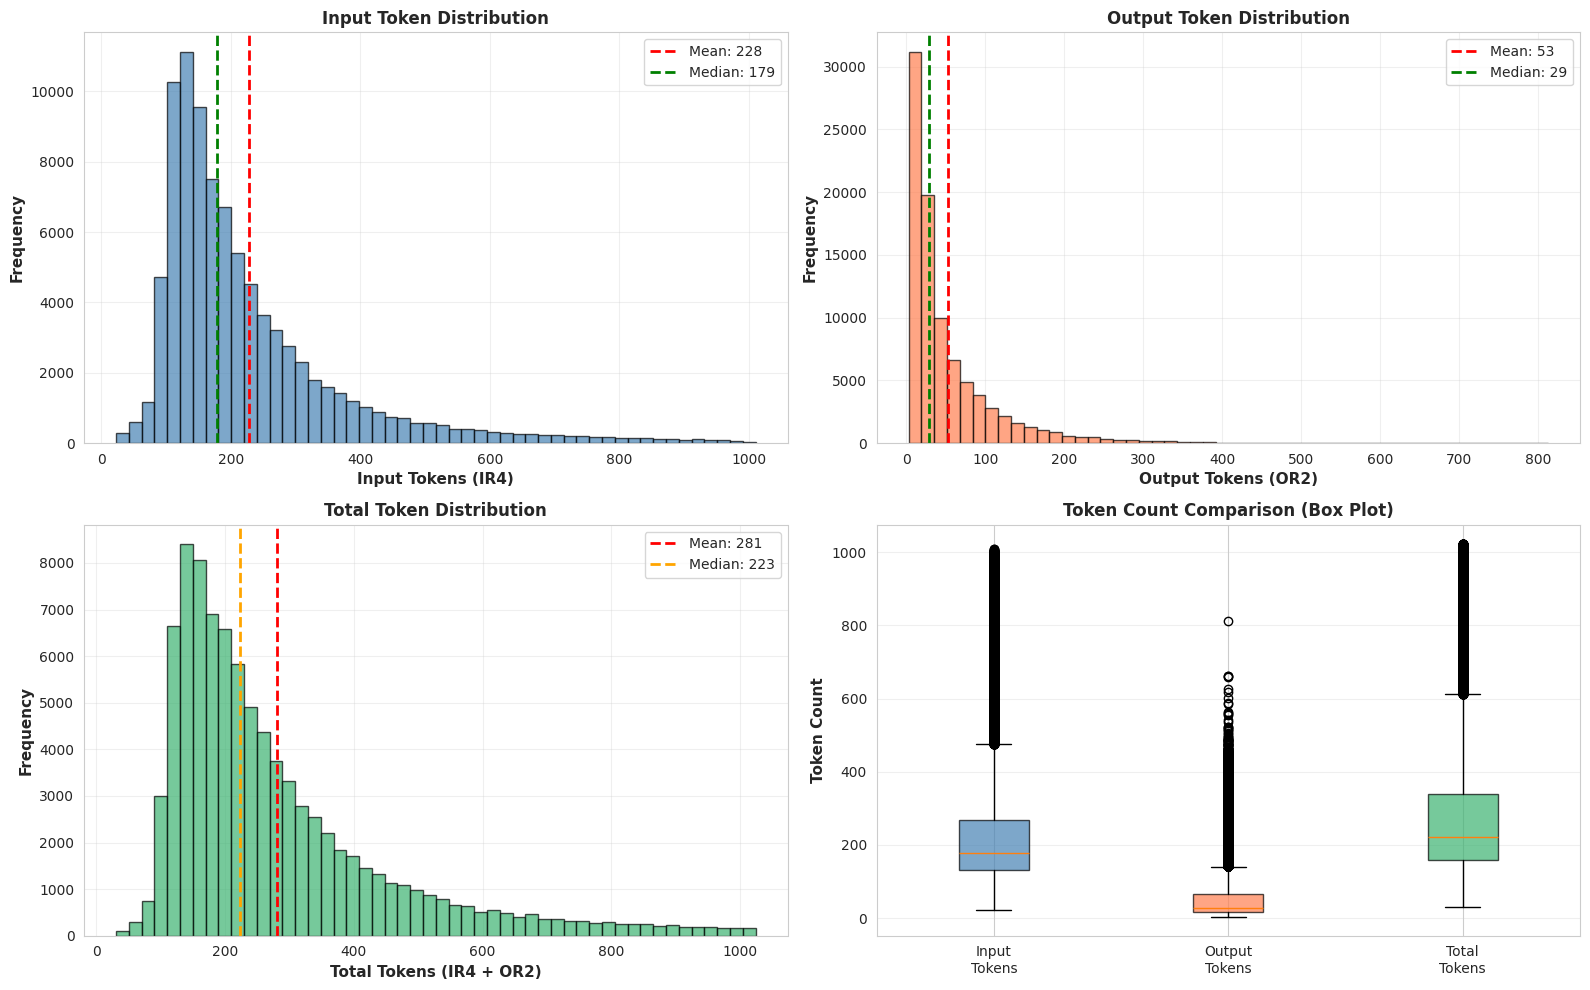

Token distribution charts displayed.


In [13]:
print("\n" + "="*80)
print("TOKEN DISTRIBUTION VISUALIZATIONS")
print("="*80 + "\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Input tokens distribution
axes[0, 0].hist(include_df['input_token'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(include_df['input_token'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {include_df["input_token"].mean():.0f}')
axes[0, 0].axvline(include_df['input_token'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {include_df["input_token"].median():.0f}')
axes[0, 0].set_xlabel('Input Tokens (IR4)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Input Token Distribution', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Output tokens distribution
axes[0, 1].hist(include_df['output_token'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(include_df['output_token'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {include_df["output_token"].mean():.0f}')
axes[0, 1].axvline(include_df['output_token'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {include_df["output_token"].median():.0f}')
axes[0, 1].set_xlabel('Output Tokens (OR2)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Output Token Distribution', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Total tokens distribution
total_tokens = include_df['input_token'] + include_df['output_token']
axes[1, 0].hist(total_tokens, bins=50, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(total_tokens.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {total_tokens.mean():.0f}')
axes[1, 0].axvline(total_tokens.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {total_tokens.median():.0f}')
axes[1, 0].set_xlabel('Total Tokens (IR4 + OR2)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Total Token Distribution', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Box plot for tokens
box_data = [include_df['input_token'], include_df['output_token'], total_tokens]
bp = axes[1, 1].boxplot(box_data, labels=['Input\nTokens', 'Output\nTokens', 'Total\nTokens'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['steelblue', 'coral', 'mediumseagreen']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 1].set_ylabel('Token Count', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Token Count Comparison (Box Plot)', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Token distribution charts displayed.")



DATA SOURCE DISTRIBUTION VISUALIZATIONS



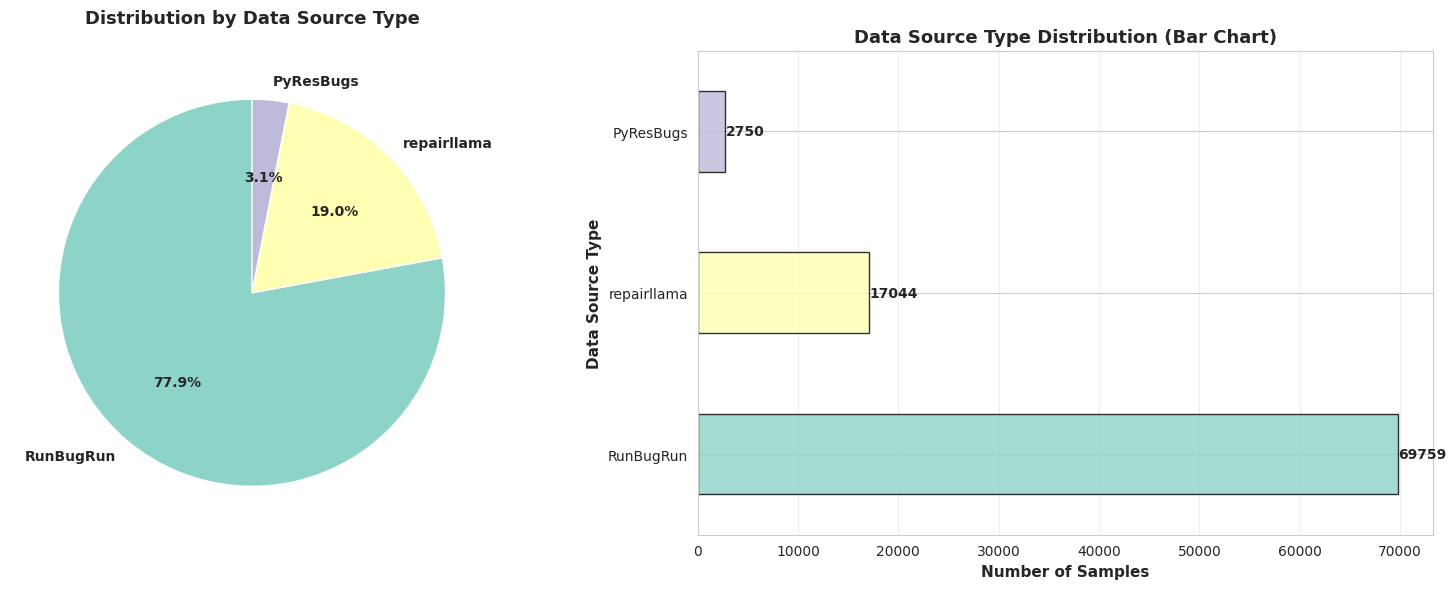

Type distribution displayed. Total types: 3


In [14]:
print("\n" + "="*80)
print("DATA SOURCE DISTRIBUTION VISUALIZATIONS")
print("="*80 + "\n")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Type distribution (pie chart)
type_counts = include_df['type'].value_counts()
colors = plt.cm.Set3(range(len(type_counts)))
wedges, texts, autotexts = axes[0].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', 
                                        colors=colors, startangle=90, textprops={'fontsize': 10, 'weight': 'bold'})
axes[0].set_title('Distribution by Data Source Type', fontsize=13, fontweight='bold', pad=20)

# Type distribution (bar chart)
type_counts.plot(kind='barh', ax=axes[1], color=colors, edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Number of Samples', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Data Source Type', fontsize=11, fontweight='bold')
axes[1].set_title('Data Source Type Distribution (Bar Chart)', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

# Add value labels on bars
for i, v in enumerate(type_counts.values):
    axes[1].text(v + 50, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Type distribution displayed. Total types: {len(type_counts)}")



TOP REPOSITORIES VISUALIZATION



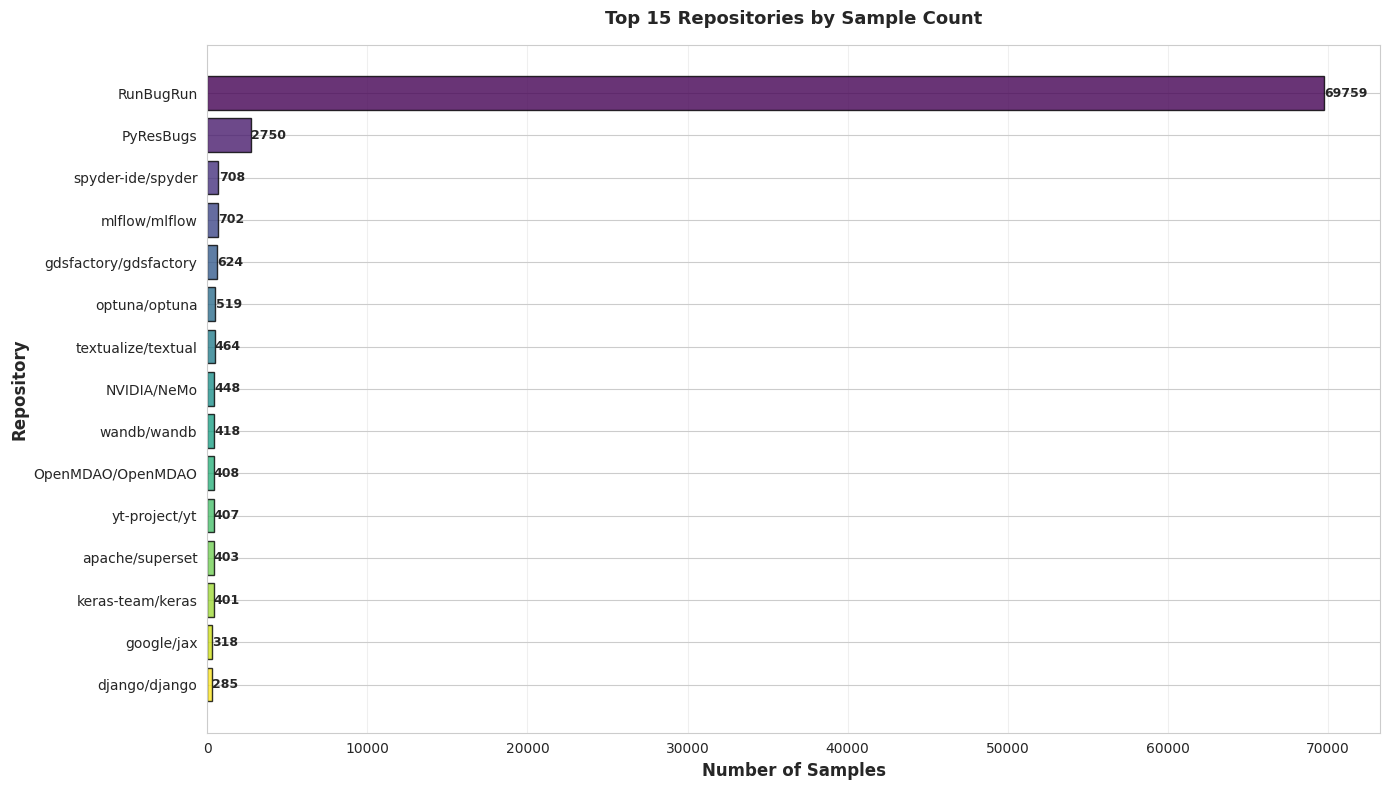

Top repositories visualization displayed. Showing top 15 of 254 total repos.


In [15]:
print("\n" + "="*80)
print("TOP REPOSITORIES VISUALIZATION")
print("="*80 + "\n")

# Top 15 repositories
top_repos = include_df['repo'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(14, 8))
colors_grad = plt.cm.viridis(np.linspace(0, 1, len(top_repos)))
bars = ax.barh(range(len(top_repos)), top_repos.values, color=colors_grad, edgecolor='black', alpha=0.8)

ax.set_yticks(range(len(top_repos)))
ax.set_yticklabels(top_repos.index, fontsize=10)
ax.set_xlabel('Number of Samples', fontsize=12, fontweight='bold')
ax.set_ylabel('Repository', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Repositories by Sample Count', fontsize=13, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.grid(alpha=0.3, axis='x')

# Add value labels
for i, (repo, count) in enumerate(top_repos.items()):
    ax.text(count + 10, i, str(count), va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print(f"Top repositories visualization displayed. Showing top 15 of {include_df['repo'].nunique()} total repos.")



CODE LENGTH DISTRIBUTION VISUALIZATIONS



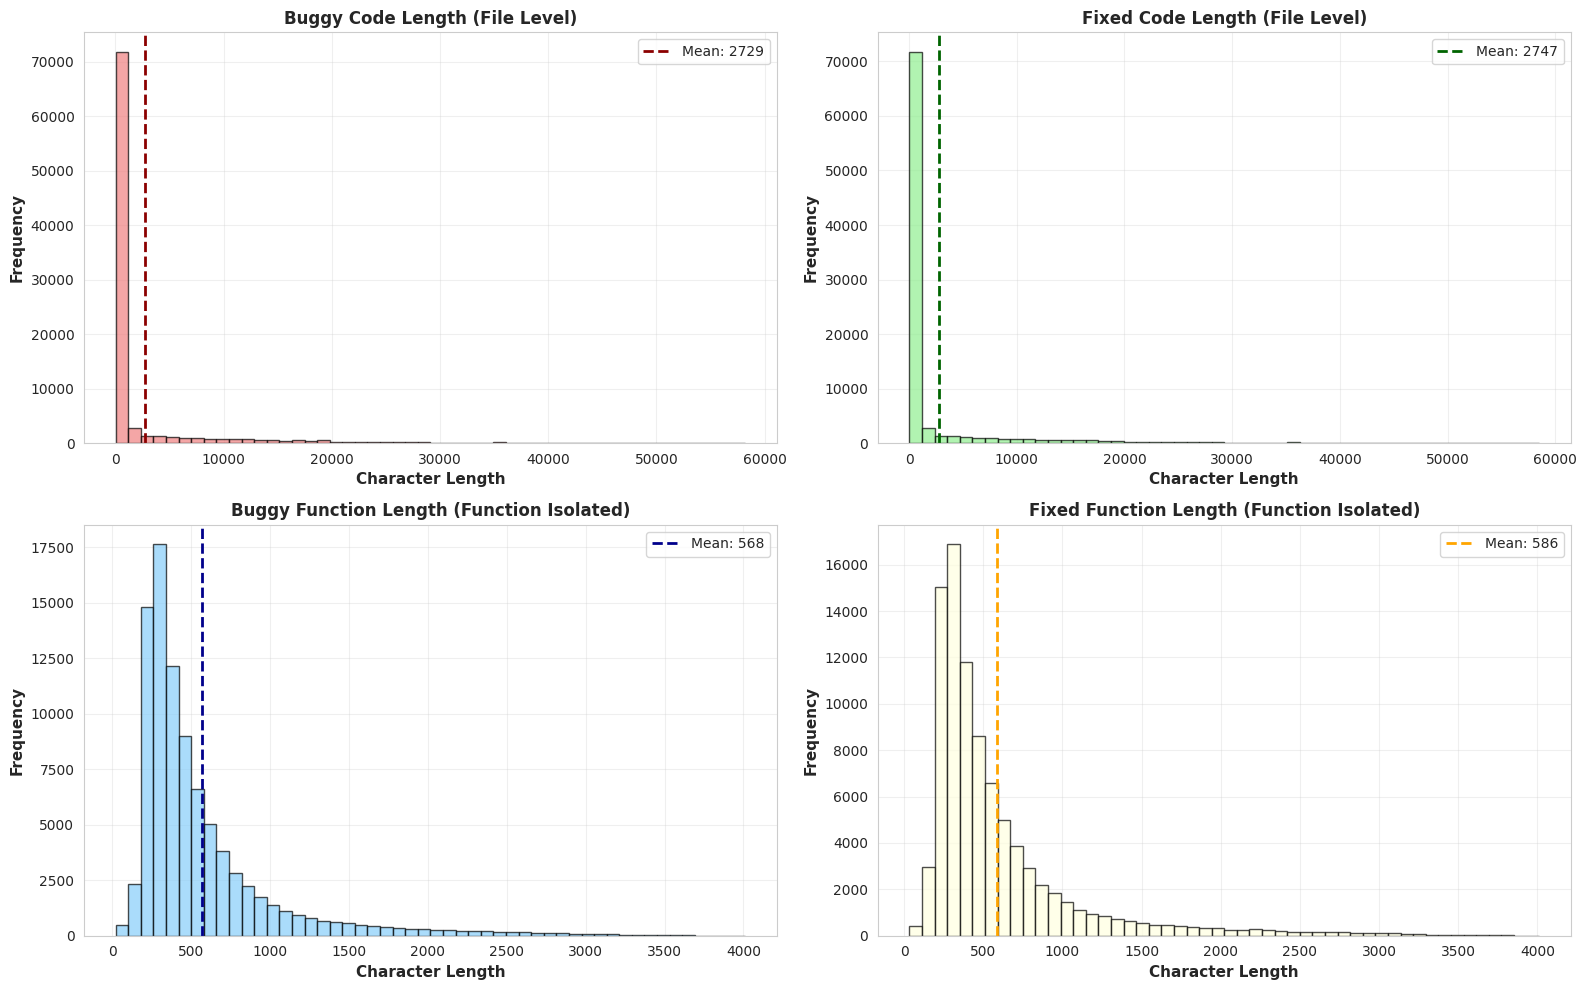

Code length distribution charts displayed.


In [16]:
print("\n" + "="*80)
print("CODE LENGTH DISTRIBUTION VISUALIZATIONS")
print("="*80 + "\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Buggy code length
axes[0, 0].hist(include_df['buggy_code_len'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(include_df['buggy_code_len'].mean(), color='darkred', linestyle='--', linewidth=2, label=f'Mean: {include_df["buggy_code_len"].mean():.0f}')
axes[0, 0].set_xlabel('Character Length', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Buggy Code Length (File Level)', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Fixed code length
axes[0, 1].hist(include_df['fixed_code_len'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(include_df['fixed_code_len'].mean(), color='darkgreen', linestyle='--', linewidth=2, label=f'Mean: {include_df["fixed_code_len"].mean():.0f}')
axes[0, 1].set_xlabel('Character Length', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Fixed Code Length (File Level)', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Buggy function length
axes[1, 0].hist(include_df['buggy_function_len'], bins=50, color='lightskyblue', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(include_df['buggy_function_len'].mean(), color='darkblue', linestyle='--', linewidth=2, label=f'Mean: {include_df["buggy_function_len"].mean():.0f}')
axes[1, 0].set_xlabel('Character Length', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Buggy Function Length (Function Isolated)', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Fixed function length
axes[1, 1].hist(include_df['fixed_function_len'], bins=50, color='lightyellow', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(include_df['fixed_function_len'].mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean: {include_df["fixed_function_len"].mean():.0f}')
axes[1, 1].set_xlabel('Character Length', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Fixed Function Length (Function Isolated)', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Code length distribution charts displayed.")



FILE LEVEL vs FUNCTION LEVEL COMPARISON



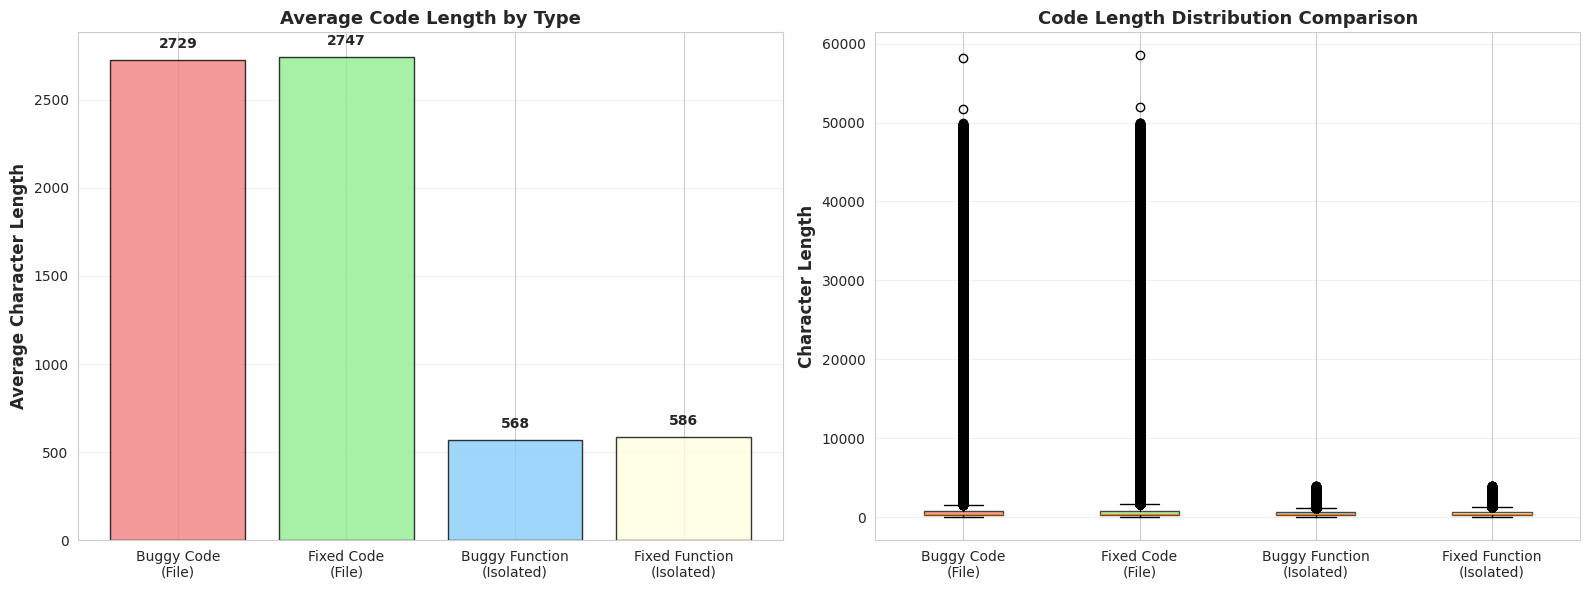

File level vs function level comparison displayed.


In [17]:
print("\n" + "="*80)
print("FILE LEVEL vs FUNCTION LEVEL COMPARISON")
print("="*80 + "\n")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Comparison of code types
code_types = ['Buggy Code\n(File)', 'Fixed Code\n(File)', 'Buggy Function\n(Isolated)', 'Fixed Function\n(Isolated)']
mean_lengths = [
    include_df['buggy_code_len'].mean(),
    include_df['fixed_code_len'].mean(),
    include_df['buggy_function_len'].mean(),
    include_df['fixed_function_len'].mean()
]
colors_comp = ['lightcoral', 'lightgreen', 'lightskyblue', 'lightyellow']

bars1 = axes[0].bar(code_types, mean_lengths, color=colors_comp, edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Average Character Length', fontsize=12, fontweight='bold')
axes[0].set_title('Average Code Length by Type', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars1, mean_lengths):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 50, f'{val:.0f}', 
                ha='center', va='bottom', fontweight='bold', fontsize=10)

# Box plot comparison
data_to_plot = [
    include_df['buggy_code_len'],
    include_df['fixed_code_len'],
    include_df['buggy_function_len'],
    include_df['fixed_function_len']
]
bp = axes[1].boxplot(data_to_plot, labels=code_types, patch_artist=True)
for patch, color in zip(bp['boxes'], colors_comp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_ylabel('Character Length', fontsize=12, fontweight='bold')
axes[1].set_title('Code Length Distribution Comparison', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("File level vs function level comparison displayed.")



TOKEN vs CODE LENGTH CORRELATION



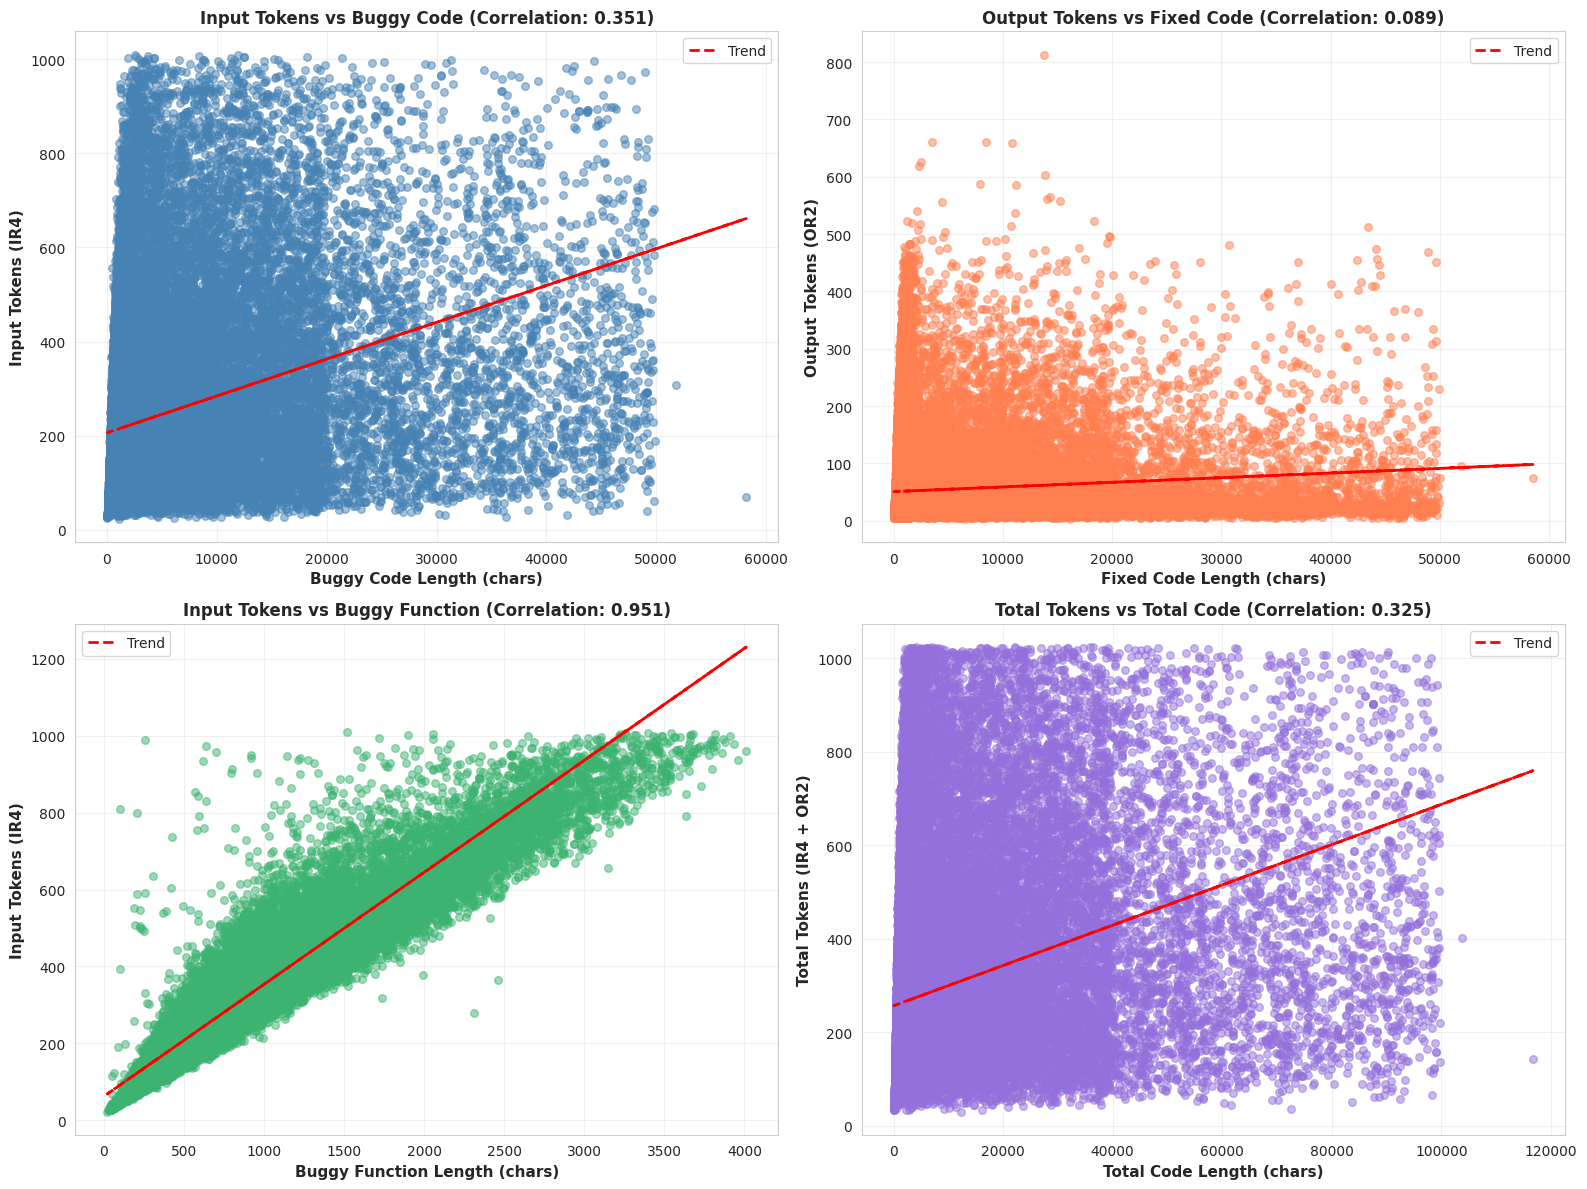

Correlations:
  IR4 tokens vs Buggy Code: 0.351
  OR2 tokens vs Fixed Code: 0.089
  IR4 tokens vs Buggy Function: 0.951
  Total tokens vs Total Code: 0.325


In [18]:
print("\n" + "="*80)
print("TOKEN vs CODE LENGTH CORRELATION")
print("="*80 + "\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Scatter: IR4 tokens vs buggy code length
axes[0, 0].scatter(include_df['buggy_code_len'], include_df['input_token'], alpha=0.5, s=30, color='steelblue')
z1 = np.polyfit(include_df['buggy_code_len'].fillna(0), include_df['input_token'], 1)
p1 = np.poly1d(z1)
axes[0, 0].plot(include_df['buggy_code_len'].fillna(0), p1(include_df['buggy_code_len'].fillna(0)), "r--", linewidth=2, label='Trend')
corr1 = include_df['buggy_code_len'].corr(include_df['input_token'])
axes[0, 0].set_xlabel('Buggy Code Length (chars)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Input Tokens (IR4)', fontsize=11, fontweight='bold')
axes[0, 0].set_title(f'Input Tokens vs Buggy Code (Correlation: {corr1:.3f})', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Scatter: OR2 tokens vs fixed code length
axes[0, 1].scatter(include_df['fixed_code_len'], include_df['output_token'], alpha=0.5, s=30, color='coral')
z2 = np.polyfit(include_df['fixed_code_len'].fillna(0), include_df['output_token'], 1)
p2 = np.poly1d(z2)
axes[0, 1].plot(include_df['fixed_code_len'].fillna(0), p2(include_df['fixed_code_len'].fillna(0)), "r--", linewidth=2, label='Trend')
corr2 = include_df['fixed_code_len'].corr(include_df['output_token'])
axes[0, 1].set_xlabel('Fixed Code Length (chars)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Output Tokens (OR2)', fontsize=11, fontweight='bold')
axes[0, 1].set_title(f'Output Tokens vs Fixed Code (Correlation: {corr2:.3f})', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Scatter: IR4 vs buggy function length
axes[1, 0].scatter(include_df['buggy_function_len'], include_df['input_token'], alpha=0.5, s=30, color='mediumseagreen')
z3 = np.polyfit(include_df['buggy_function_len'].fillna(0), include_df['input_token'], 1)
p3 = np.poly1d(z3)
axes[1, 0].plot(include_df['buggy_function_len'].fillna(0), p3(include_df['buggy_function_len'].fillna(0)), "r--", linewidth=2, label='Trend')
corr3 = include_df['buggy_function_len'].corr(include_df['input_token'])
axes[1, 0].set_xlabel('Buggy Function Length (chars)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Input Tokens (IR4)', fontsize=11, fontweight='bold')
axes[1, 0].set_title(f'Input Tokens vs Buggy Function (Correlation: {corr3:.3f})', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Scatter: Total tokens vs total code length
total_code = include_df['buggy_code_len'] + include_df['fixed_code_len']
total_tok = include_df['input_token'] + include_df['output_token']
axes[1, 1].scatter(total_code, total_tok, alpha=0.5, s=30, color='mediumpurple')
z4 = np.polyfit(total_code.fillna(0), total_tok, 1)
p4 = np.poly1d(z4)
axes[1, 1].plot(total_code.fillna(0), p4(total_code.fillna(0)), "r--", linewidth=2, label='Trend')
corr4 = total_code.corr(total_tok)
axes[1, 1].set_xlabel('Total Code Length (chars)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Total Tokens (IR4 + OR2)', fontsize=11, fontweight='bold')
axes[1, 1].set_title(f'Total Tokens vs Total Code (Correlation: {corr4:.3f})', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Correlations:")
print(f"  IR4 tokens vs Buggy Code: {corr1:.3f}")
print(f"  OR2 tokens vs Fixed Code: {corr2:.3f}")
print(f"  IR4 tokens vs Buggy Function: {corr3:.3f}")
print(f"  Total tokens vs Total Code: {corr4:.3f}")



TOKEN ANALYSIS BY DATA SOURCE TYPE

Input Tokens (IR4) by Type:
  RunBugRun: Mean=195.89, Median=168.00, Std=96.89
  repairllama: Mean=355.85, Median=303.50, Std=229.60
  PyResBugs: Mean=236.61, Median=173.50, Std=191.16

Output Tokens (OR2) by Type:
  RunBugRun: Mean=49.49, Median=27.00, Std=55.24
  repairllama: Mean=64.44, Median=34.00, Std=76.04
  PyResBugs: Mean=71.46, Median=38.00, Std=83.34


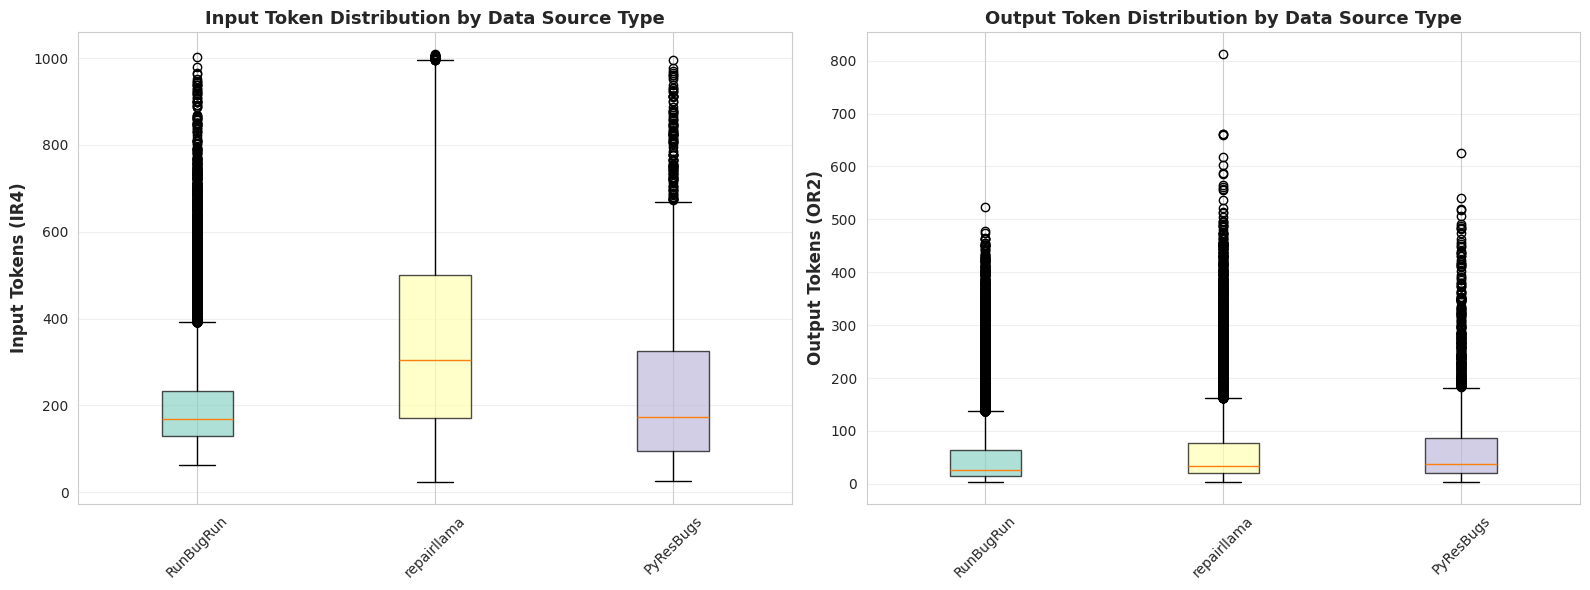


Visualization displayed.


In [19]:
print("\n" + "="*80)
print("TOKEN ANALYSIS BY DATA SOURCE TYPE")
print("="*80 + "\n")

# Statistics by type
print("Input Tokens (IR4) by Type:")
for dtype in include_df['type'].unique():
    subset = include_df[include_df['type'] == dtype]['input_token']
    print(f"  {dtype}: Mean={subset.mean():.2f}, Median={subset.median():.2f}, Std={subset.std():.2f}")

print("\nOutput Tokens (OR2) by Type:")
for dtype in include_df['type'].unique():
    subset = include_df[include_df['type'] == dtype]['output_token']
    print(f"  {dtype}: Mean={subset.mean():.2f}, Median={subset.median():.2f}, Std={subset.std():.2f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot for input tokens by type
type_order = include_df['type'].unique()
data_input = [include_df[include_df['type'] == t]['input_token'].values for t in type_order]
bp1 = axes[0].boxplot(data_input, labels=type_order, patch_artist=True)
for patch, color in zip(bp1['boxes'], plt.cm.Set3(range(len(type_order)))):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel('Input Tokens (IR4)', fontsize=12, fontweight='bold')
axes[0].set_title('Input Token Distribution by Data Source Type', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=45)

# Box plot for output tokens by type
data_output = [include_df[include_df['type'] == t]['output_token'].values for t in type_order]
bp2 = axes[1].boxplot(data_output, labels=type_order, patch_artist=True)
for patch, color in zip(bp2['boxes'], plt.cm.Set3(range(len(type_order)))):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Output Tokens (OR2)', fontsize=12, fontweight='bold')
axes[1].set_title('Output Token Distribution by Data Source Type', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nVisualization displayed.")



CODE CHANGE MAGNITUDE ANALYSIS

File-Level Code Changes:
  Mean magnitude (absolute difference): 29.79 chars
  Median magnitude: 8.00 chars
  Min: 0 chars
  Max: 2736 chars
  Std Dev: 68.91

Function-Level Code Changes:
  Mean magnitude (absolute difference): 29.74 chars
  Median magnitude: 8.00 chars
  Min: 0 chars
  Max: 2736 chars
  Std Dev: 68.60

--------------------------------------------------------------------------------
Change Size Categories (File Level):
  Small (0-100 chars): 84330 (94.17%)
  Medium (101-500 chars): 4850 (5.42%)
  Large (501-1000 chars): 328 (0.37%)
  Extra Large (>1000 chars): 45 (0.05%)

Change Size Categories (Function Level):
  Small (0-50 chars): 75350 (84.14%)
  Medium (51-200 chars): 12230 (13.66%)
  Large (201-500 chars): 1603 (1.79%)
  Extra Large (>500 chars): 370 (0.41%)


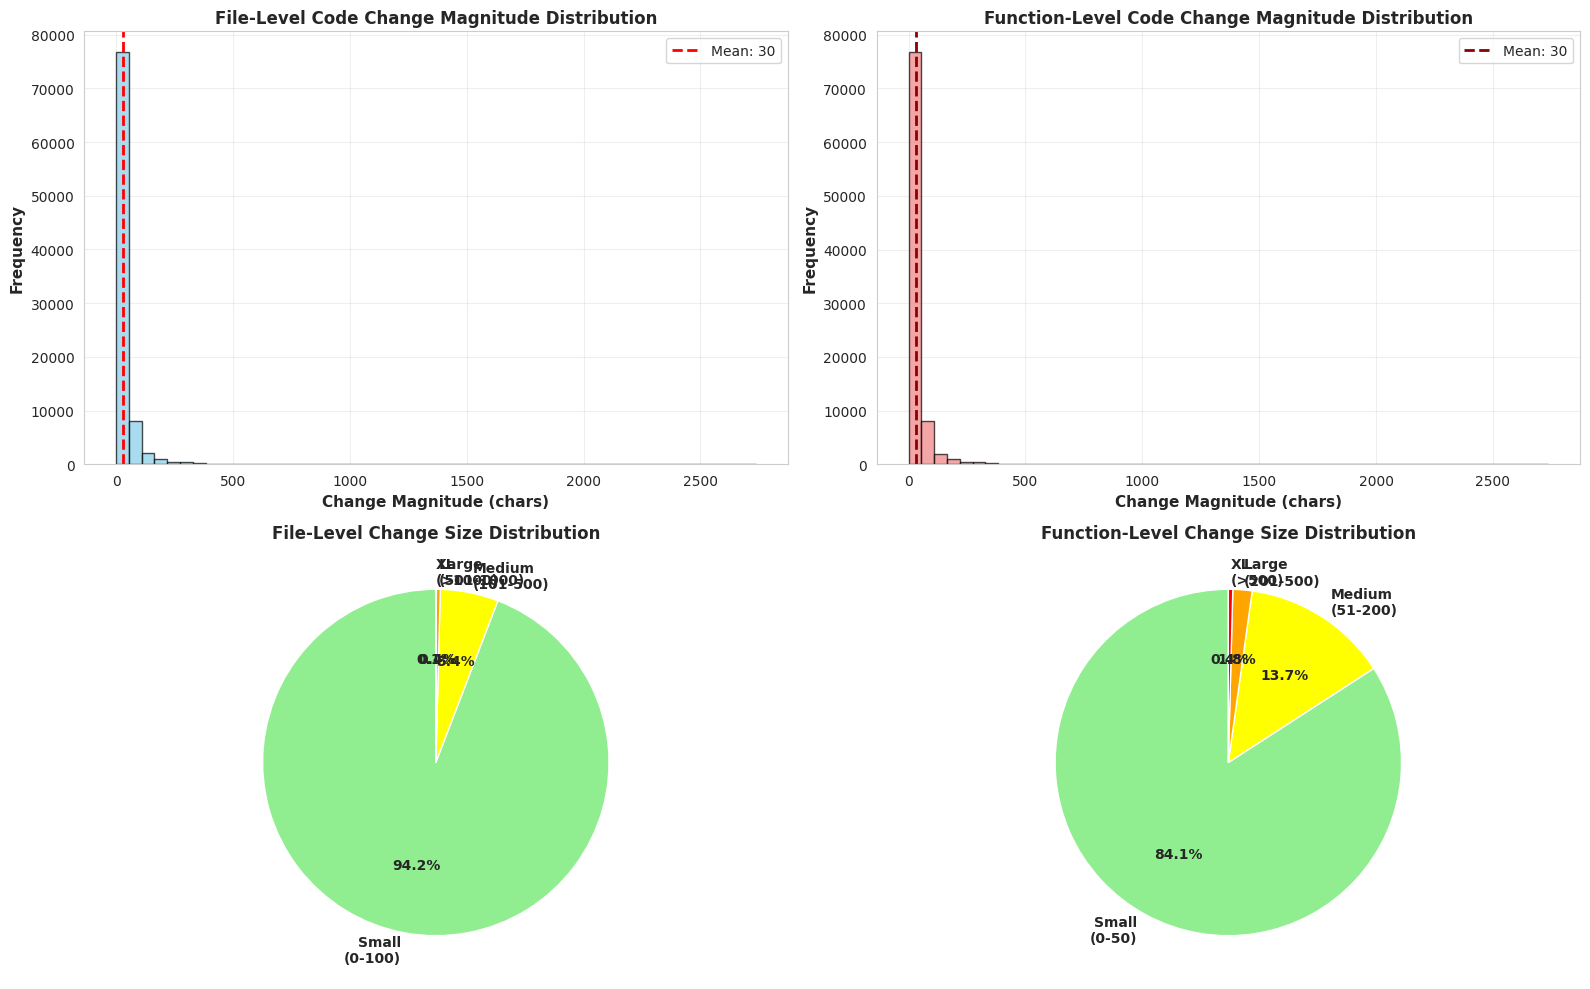


Code change analysis visualizations displayed.


In [20]:
print("\n" + "="*80)
print("CODE CHANGE MAGNITUDE ANALYSIS")
print("="*80 + "\n")

# Calculate change magnitudes
print("File-Level Code Changes:")
print(f"  Mean magnitude (absolute difference): {include_df['file_diff'].mean():.2f} chars")
print(f"  Median magnitude: {include_df['file_diff'].median():.2f} chars")
print(f"  Min: {include_df['file_diff'].min()} chars")
print(f"  Max: {include_df['file_diff'].max()} chars")
print(f"  Std Dev: {include_df['file_diff'].std():.2f}")

print("\nFunction-Level Code Changes:")
print(f"  Mean magnitude (absolute difference): {include_df['func_diff'].mean():.2f} chars")
print(f"  Median magnitude: {include_df['func_diff'].median():.2f} chars")
print(f"  Min: {include_df['func_diff'].min()} chars")
print(f"  Max: {include_df['func_diff'].max()} chars")
print(f"  Std Dev: {include_df['func_diff'].std():.2f}")

# Distribution by size category
print("\n" + "-"*80)
print("Change Size Categories (File Level):")
small_file = (include_df['file_diff'] <= 100).sum()
medium_file = ((include_df['file_diff'] > 100) & (include_df['file_diff'] <= 500)).sum()
large_file = ((include_df['file_diff'] > 500) & (include_df['file_diff'] <= 1000)).sum()
xlarge_file = (include_df['file_diff'] > 1000).sum()
print(f"  Small (0-100 chars): {small_file} ({small_file/len(include_df)*100:.2f}%)")
print(f"  Medium (101-500 chars): {medium_file} ({medium_file/len(include_df)*100:.2f}%)")
print(f"  Large (501-1000 chars): {large_file} ({large_file/len(include_df)*100:.2f}%)")
print(f"  Extra Large (>1000 chars): {xlarge_file} ({xlarge_file/len(include_df)*100:.2f}%)")

print("\nChange Size Categories (Function Level):")
small_func = (include_df['func_diff'] <= 50).sum()
medium_func = ((include_df['func_diff'] > 50) & (include_df['func_diff'] <= 200)).sum()
large_func = ((include_df['func_diff'] > 200) & (include_df['func_diff'] <= 500)).sum()
xlarge_func = (include_df['func_diff'] > 500).sum()
print(f"  Small (0-50 chars): {small_func} ({small_func/len(include_df)*100:.2f}%)")
print(f"  Medium (51-200 chars): {medium_func} ({medium_func/len(include_df)*100:.2f}%)")
print(f"  Large (201-500 chars): {large_func} ({large_func/len(include_df)*100:.2f}%)")
print(f"  Extra Large (>500 chars): {xlarge_func} ({xlarge_func/len(include_df)*100:.2f}%)")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# File-level change magnitude histogram
axes[0, 0].hist(include_df['file_diff'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(include_df['file_diff'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {include_df["file_diff"].mean():.0f}')
axes[0, 0].set_xlabel('Change Magnitude (chars)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 0].set_title('File-Level Code Change Magnitude Distribution', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Function-level change magnitude histogram
axes[0, 1].hist(include_df['func_diff'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(include_df['func_diff'].mean(), color='darkred', linestyle='--', linewidth=2, label=f'Mean: {include_df["func_diff"].mean():.0f}')
axes[0, 1].set_xlabel('Change Magnitude (chars)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Function-Level Code Change Magnitude Distribution', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# File-level categories pie chart
file_cats = [small_file, medium_file, large_file, xlarge_file]
file_labels = ['Small\n(0-100)', 'Medium\n(101-500)', 'Large\n(501-1000)', 'XL\n(>1000)']
colors_pie = ['lightgreen', 'yellow', 'orange', 'red']
axes[1, 0].pie(file_cats, labels=file_labels, autopct='%1.1f%%', colors=colors_pie, startangle=90, textprops={'fontsize': 10, 'weight': 'bold'})
axes[1, 0].set_title('File-Level Change Size Distribution', fontsize=12, fontweight='bold')

# Function-level categories pie chart
func_cats = [small_func, medium_func, large_func, xlarge_func]
func_labels = ['Small\n(0-50)', 'Medium\n(51-200)', 'Large\n(201-500)', 'XL\n(>500)']
axes[1, 1].pie(func_cats, labels=func_labels, autopct='%1.1f%%', colors=colors_pie, startangle=90, textprops={'fontsize': 10, 'weight': 'bold'})
axes[1, 1].set_title('Function-Level Change Size Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nCode change analysis visualizations displayed.")


In [21]:
print("\n" + "="*80)
print("DETAILED STATISTICS BY TOP REPOSITORIES")
print("="*80 + "\n")

top_repos_analyze = include_df['repo'].value_counts().head(10).index

for repo in top_repos_analyze:
    repo_data = include_df[include_df['repo'] == repo]
    print(f"\n{repo}:")
    print(f"  Samples: {len(repo_data)}")
    print(f"  Input tokens - Mean: {repo_data['input_token'].mean():.2f}, Std: {repo_data['input_token'].std():.2f}")
    print(f"  Output tokens - Mean: {repo_data['output_token'].mean():.2f}, Std: {repo_data['output_token'].std():.2f}")
    print(f"  Code length - Mean: {(repo_data['buggy_code_len'] + repo_data['fixed_code_len']).mean():.2f}")



DETAILED STATISTICS BY TOP REPOSITORIES


RunBugRun:
  Samples: 69759
  Input tokens - Mean: 195.89, Std: 96.89
  Output tokens - Mean: 49.49, Std: 55.24
  Code length - Mean: 877.61

PyResBugs:
  Samples: 2750
  Input tokens - Mean: 236.61, Std: 191.16
  Output tokens - Mean: 71.46, Std: 83.34
  Code length - Mean: 1390.02

spyder-ide/spyder:
  Samples: 708
  Input tokens - Mean: 323.38, Std: 212.65
  Output tokens - Mean: 63.44, Std: 75.33
  Code length - Mean: 34633.78

mlflow/mlflow:
  Samples: 702
  Input tokens - Mean: 366.96, Std: 209.19
  Output tokens - Mean: 83.95, Std: 88.43
  Code length - Mean: 31494.17

gdsfactory/gdsfactory:
  Samples: 624
  Input tokens - Mean: 468.68, Std: 250.98
  Output tokens - Mean: 58.21, Std: 66.58
  Code length - Mean: 16542.81

optuna/optuna:
  Samples: 519
  Input tokens - Mean: 387.12, Std: 223.16
  Output tokens - Mean: 63.56, Std: 72.29
  Code length - Mean: 27557.67

textualize/textual:
  Samples: 464
  Input tokens - Mean: 298.99, Std: 2


CORRELATION MATRIX & HEATMAP

Correlation Matrix:
                    input_token  output_token  buggy_code_len  fixed_code_len  \
input_token               1.000         0.300           0.351           0.351   
output_token              0.300         1.000           0.085           0.089   
buggy_code_len            0.351         0.085           1.000           1.000   
fixed_code_len            0.351         0.089           1.000           1.000   
buggy_function_len        0.951         0.228           0.447           0.447   
fixed_function_len        0.938         0.271           0.457           0.459   
file_diff                 0.192         0.432           0.219           0.226   
func_diff                 0.192         0.430           0.220           0.227   

                    buggy_function_len  fixed_function_len  file_diff  \
input_token                      0.951               0.938      0.192   
output_token                     0.228               0.271      0.432   


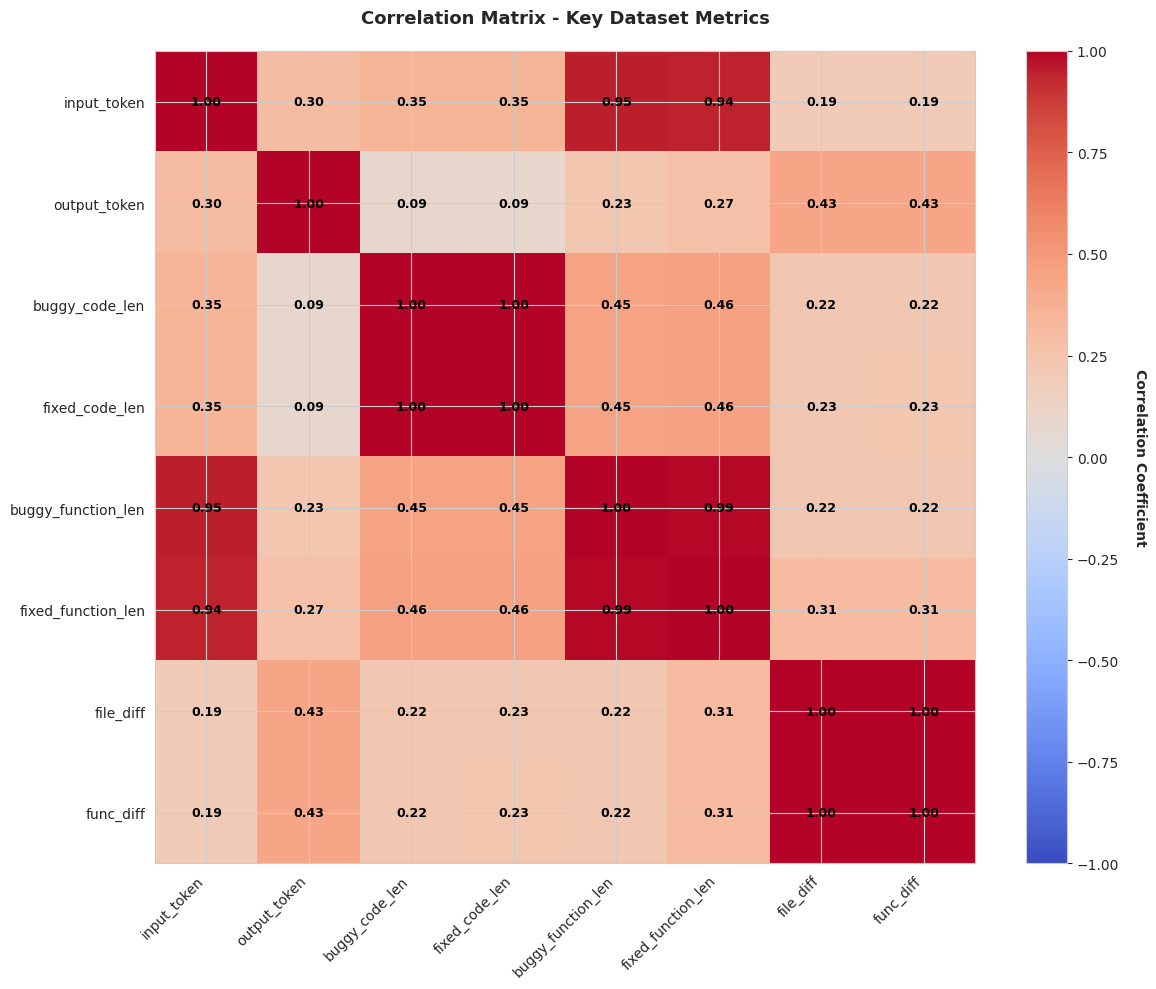


Correlation heatmap displayed.


In [22]:
print("\n" + "="*80)
print("CORRELATION MATRIX & HEATMAP")
print("="*80 + "\n")

# Select numeric columns for correlation
numeric_cols = ['input_token', 'output_token', 'buggy_code_len', 'fixed_code_len', 
                'buggy_function_len', 'fixed_function_len', 'file_diff', 'func_diff']
corr_matrix = include_df[numeric_cols].corr()

print("Correlation Matrix:")
print(corr_matrix.round(3))

# Heatmap visualization
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)

# Set ticks and labels
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(numeric_cols, fontsize=10)

# Add correlation values in cells
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                      ha="center", va="center", color="black", fontweight='bold', fontsize=9)

ax.set_title('Correlation Matrix - Key Dataset Metrics', fontsize=13, fontweight='bold', pad=20)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Correlation Coefficient', rotation=270, labelpad=20, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nCorrelation heatmap displayed.")


In [25]:
print("\n" + "="*80)
print("FINAL COMPREHENSIVE SUMMARY")
print("="*80)

summary = f"""
DATASET OVERVIEW
================
Total Samples: {len(include_df):,}
Total Unique Repositories: {include_df['repo'].nunique()}
Data Sources (Types): {include_df['type'].nunique()}
  - {', '.join([f"{t}: {(include_df['type']==t).sum()}" for t in include_df['type'].unique()])}

TOKEN STATISTICS
================
Input Tokens (IR4):
  - Mean: {include_df['input_token'].mean():.2f}
  - Median: {include_df['input_token'].median():.0f}
  - Range: {include_df['input_token'].min()} - {include_df['input_token'].max()}
  - Std Dev: {include_df['input_token'].std():.2f}

Output Tokens (OR2):
  - Mean: {include_df['output_token'].mean():.2f}
  - Median: {include_df['output_token'].median():.0f}
  - Range: {include_df['output_token'].min()} - {include_df['output_token'].max()}
  - Std Dev: {include_df['output_token'].std():.2f}

Total Tokens (IR4 + OR2):
  - Mean: {(include_df['input_token'] + include_df['output_token']).mean():.2f}
  - Median: {(include_df['input_token'] + include_df['output_token']).median():.0f}
  - Context Limit: 1024 tokens

CODE LENGTH STATISTICS (Characters)
====================================
File Level:
  - Buggy Code: Mean {include_df['buggy_code_len'].mean():.0f}, Median {include_df['buggy_code_len'].median():.0f}
  - Fixed Code: Mean {include_df['fixed_code_len'].mean():.0f}, Median {include_df['fixed_code_len'].median():.0f}
  - Change Magnitude: Mean {include_df['file_diff'].mean():.0f}

Function Level:
  - Buggy Function: Mean {include_df['buggy_function_len'].mean():.0f}, Median {include_df['buggy_function_len'].median():.0f}
  - Fixed Function: Mean {include_df['fixed_function_len'].mean():.0f}, Median {include_df['fixed_function_len'].median():.0f}
  - Change Magnitude: Mean {include_df['func_diff'].mean():.0f}

TOP CORRELATIONS
================
Strong Positive Correlations (>0.9):
"""

# Find strong correlations
for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        corr_val = corr_matrix.iloc[i, j]
        if corr_val > 0.9:
            summary += f"  - {numeric_cols[i]} ↔ {numeric_cols[j]}: {corr_val:.3f}\n"

summary += f"""
DATA QUALITY
============
Missing Values: {include_df.isnull().sum().sum()} total
  - IR4: {include_df['IR4'].isnull().sum()}
  - OR2: {include_df['OR2'].isnull().sum()}
  - buggy_code: {include_df['buggy_code'].isnull().sum()}
  - fixed_code: {include_df['fixed_code'].isnull().sum()}
  - buggy_function: {include_df['buggy_function'].isnull().sum()}
  - fixed_function: {include_df['fixed_function'].isnull().sum()}


KEY INSIGHTS
============
1. Token Distribution: Input tokens (mean {include_df['input_token'].mean():.0f}) are generally larger 
   than output tokens (mean {include_df['output_token'].mean():.0f}), reflecting the nature of bug 
   repair tasks where context/buggy code is larger than fixes.

2. Code Change Scale: Most bug fixes are relatively small 
   ({(include_df['func_diff'] <= 200).sum() / len(include_df) * 100:.1f}% of function-level changes 
   are ≤200 chars).

3. File vs Function Level: Function-level representations are significantly more compact 
   (avg {include_df['buggy_function_len'].mean():.0f} chars) compared to file-level 
   ({include_df['buggy_code_len'].mean():.0f} chars).

4. Strong Token-Code Correlation: {corr_matrix.loc['input_token', 'buggy_code_len']:.3f} correlation 
   between input tokens and buggy code length suggests tokenization consistency.

5. Data Source Diversity: Dataset includes {', '.join(include_df['type'].unique())} sources, 
   with top repository contributing {(include_df['repo'].value_counts().iloc[0] / len(include_df) * 100):.1f}% of samples.
"""

print(summary)



FINAL COMPREHENSIVE SUMMARY

DATASET OVERVIEW
Total Samples: 89,553
Total Unique Repositories: 254
Data Sources (Types): 3
  - RunBugRun: 69759, repairllama: 17044, PyResBugs: 2750

TOKEN STATISTICS
Input Tokens (IR4):
  - Mean: 227.59
  - Median: 179
  - Range: 23 - 1010
  - Std Dev: 149.61

Output Tokens (OR2):
  - Mean: 53.01
  - Median: 29
  - Range: 3 - 813
  - Std Dev: 61.12

Total Tokens (IR4 + OR2):
  - Mean: 280.60
  - Median: 223
  - Context Limit: 1024 tokens

CODE LENGTH STATISTICS (Characters)
File Level:
  - Buggy Code: Mean 2729, Median 429
  - Fixed Code: Mean 2747, Median 439
  - Change Magnitude: Mean 30

Function Level:
  - Buggy Function: Mean 568, Median 401
  - Fixed Function: Mean 586, Median 413
  - Change Magnitude: Mean 30

TOP CORRELATIONS
Strong Positive Correlations (>0.9):
  - input_token ↔ buggy_function_len: 0.951
  - input_token ↔ fixed_function_len: 0.938
  - buggy_code_len ↔ fixed_code_len: 1.000
  - buggy_function_len ↔ fixed_function_len: 0.990
  -


COMPREHENSIVE DASHBOARD



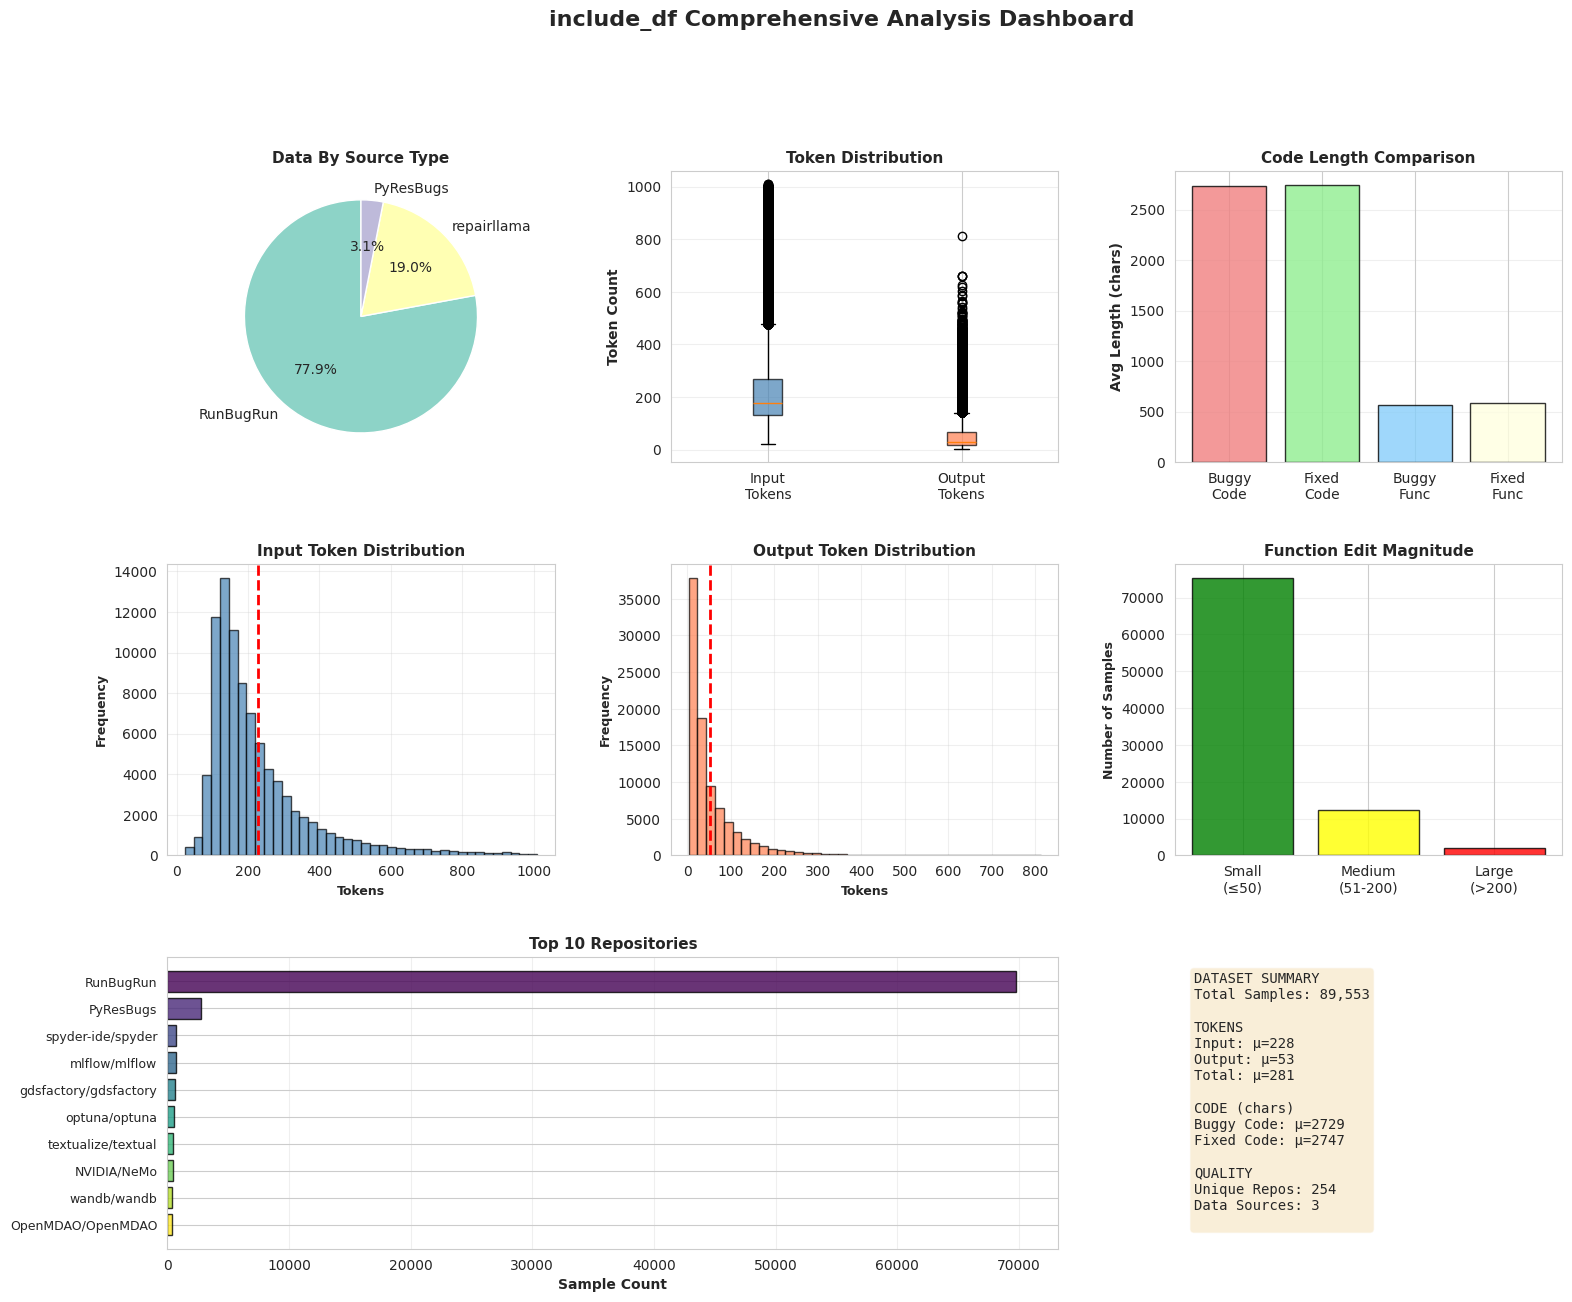

Comprehensive dashboard displayed and saved as 'dataset_analysis_dashboard.png'


In [27]:
print("\n" + "="*80)
print("COMPREHENSIVE DASHBOARD")
print("="*80 + "\n")

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1. Type distribution pie
ax1 = fig.add_subplot(gs[0, 0])
type_counts = include_df['type'].value_counts()
ax1.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', 
        colors=plt.cm.Set3(range(len(type_counts))), startangle=90)
ax1.set_title('Data By Source Type', fontweight='bold', fontsize=11)

# 2. Token distribution
ax2 = fig.add_subplot(gs[0, 1])
box_data_tok = [include_df['input_token'], include_df['output_token']]
bp = ax2.boxplot(box_data_tok, labels=['Input\nTokens', 'Output\nTokens'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['steelblue', 'coral']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_ylabel('Token Count', fontweight='bold', fontsize=10)
ax2.set_title('Token Distribution', fontweight='bold', fontsize=11)
ax2.grid(alpha=0.3, axis='y')

# 3. Code length comparison
ax3 = fig.add_subplot(gs[0, 2])
code_types_short = ['Buggy\nCode', 'Fixed\nCode', 'Buggy\nFunc', 'Fixed\nFunc']
code_means = [
    include_df['buggy_code_len'].mean(),
    include_df['fixed_code_len'].mean(),
    include_df['buggy_function_len'].mean(),
    include_df['fixed_function_len'].mean()
]
colors_code = ['lightcoral', 'lightgreen', 'lightskyblue', 'lightyellow']
ax3.bar(code_types_short, code_means, color=colors_code, edgecolor='black', alpha=0.8)
ax3.set_ylabel('Avg Length (chars)', fontweight='bold', fontsize=10)
ax3.set_title('Code Length Comparison', fontweight='bold', fontsize=11)
ax3.grid(alpha=0.3, axis='y')

# 4. Input token distribution histogram
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(include_df['input_token'], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
ax4.axvline(include_df['input_token'].mean(), color='red', linestyle='--', linewidth=2)
ax4.set_xlabel('Tokens', fontsize=9, fontweight='bold')
ax4.set_ylabel('Frequency', fontsize=9, fontweight='bold')
ax4.set_title('Input Token Distribution', fontweight='bold', fontsize=11)
ax4.grid(alpha=0.3)

# 5. Output token distribution histogram
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(include_df['output_token'], bins=40, color='coral', edgecolor='black', alpha=0.7)
ax5.axvline(include_df['output_token'].mean(), color='red', linestyle='--', linewidth=2)
ax5.set_xlabel('Tokens', fontsize=9, fontweight='bold')
ax5.set_ylabel('Frequency', fontsize=9, fontweight='bold')
ax5.set_title('Output Token Distribution', fontweight='bold', fontsize=11)
ax5.grid(alpha=0.3)

# 6. Code change magnitude
ax6 = fig.add_subplot(gs[1, 2])
change_cats = ['Small\n(≤50)', 'Medium\n(51-200)', 'Large\n(>200)']
change_vals = [
    (include_df['func_diff'] <= 50).sum(),
    ((include_df['func_diff'] > 50) & (include_df['func_diff'] <= 200)).sum(),
    (include_df['func_diff'] > 200).sum()
]
ax6.bar(change_cats, change_vals, color=['green', 'yellow', 'red'], edgecolor='black', alpha=0.8)
ax6.set_ylabel('Number of Samples', fontsize=9, fontweight='bold')
ax6.set_title('Function Edit Magnitude', fontweight='bold', fontsize=11)
ax6.grid(alpha=0.3, axis='y')

# 7. Top repositories
ax7 = fig.add_subplot(gs[2, :2])
top_repos_plot = include_df['repo'].value_counts().head(10)
colors_repo = plt.cm.viridis(np.linspace(0, 1, len(top_repos_plot)))
ax7.barh(range(len(top_repos_plot)), top_repos_plot.values, color=colors_repo, edgecolor='black', alpha=0.8)
ax7.set_yticks(range(len(top_repos_plot)))
ax7.set_yticklabels(top_repos_plot.index, fontsize=9)
ax7.set_xlabel('Sample Count', fontsize=10, fontweight='bold')
ax7.set_title('Top 10 Repositories', fontweight='bold', fontsize=11)
ax7.invert_yaxis()
ax7.grid(alpha=0.3, axis='x')

# 8. Statistics summary text
ax8 = fig.add_subplot(gs[2, 2])
ax8.axis('off')
stats_text = f"""DATASET SUMMARY
Total Samples: {len(include_df):,}

TOKENS
Input: μ={include_df['input_token'].mean():.0f}
Output: μ={include_df['output_token'].mean():.0f}
Total: μ={(include_df['input_token']+include_df['output_token']).mean():.0f}

CODE (chars)
Buggy Code: μ={include_df['buggy_code_len'].mean():.0f}
Fixed Code: μ={include_df['fixed_code_len'].mean():.0f}

QUALITY
Unique Repos: {include_df['repo'].nunique()}
Data Sources: {include_df['type'].nunique()}
"""
ax8.text(0.05, 0.95, stats_text, transform=ax8.transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('include_df Comprehensive Analysis Dashboard', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('dataset_analysis_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("Comprehensive dashboard displayed and saved as 'dataset_analysis_dashboard.png'")


## Function Pair Validation - Verification Script